In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_excel(r"C:\Users\DELL\Videos\Online Retail.xlsx")
df.to_csv("Online Retail.csv", index=False, encoding='latin1')

In [3]:
df = pd.read_csv("Online Retail.csv", encoding='latin1', parse_dates=['InvoiceDate'])
print(f"Initial shape: {df.shape}")
print(df.head())

Initial shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [32]:
total_revenue = (df['Quantity'] * df['UnitPrice']).sum()
print(total_revenue)

7968153.253999998


In [5]:
df.duplicated().sum()

np.int64(5268)

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
# Convert to numeric, coerce errors to NaN (e.g., if there are commas or spaces)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

In [9]:
# Drop rows where either is NaN (non-convertible)
df = df.dropna(subset=['Quantity', 'UnitPrice'])
print(f"After numeric conversion: {df.shape}")

After numeric conversion: (541909, 8)


In [10]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Keep only positive Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [11]:
# Remove duplicates
df = df.drop_duplicates()

# Cap outliers (99.5th percentile)
for col in ['Quantity', 'UnitPrice']:
    cap = df[col].quantile(0.995)
    df[col] = np.where(df[col] > cap, cap, df[col])

print(f"After cleaning: {df.shape}")

After cleaning: (392692, 8)


In [12]:
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']   # Now safe – columns are numeric

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalSpend', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique'),
    WeekendRatio=('InvoiceDate', lambda dates: dates.dt.dayofweek.isin([5,6]).mean())
)

customer_df['AvgBasketValue'] = customer_df['Monetary'] / customer_df['Frequency']
customer_df = customer_df[customer_df['Monetary'] > 0]
print(f"Customers with positive spend: {len(customer_df)}")

Customers with positive spend: 4338


In [13]:
df_raw = pd.read_csv("Online Retail.csv", encoding='latin1', parse_dates=['InvoiceDate'])
df_raw['Quantity'] = pd.to_numeric(df_raw['Quantity'], errors='coerce')
returns = df_raw[df_raw['Quantity'] < 0].groupby('CustomerID')['InvoiceNo'].nunique().rename('ReturnsInvoices')
customer_df = customer_df.join(returns, how='left').fillna(0)
customer_df['ReturnsRatio'] = customer_df['ReturnsInvoices'] / customer_df['Frequency']
customer_df = customer_df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Final customer_df: {customer_df.shape}")


Final customer_df: (4338, 9)


In [14]:
for col in ['Monetary', 'Frequency', 'AvgBasketValue']:
    customer_df[f'{col}_log'] = np.log1p(customer_df[col])

customer_df['Recency_inv'] = customer_df['Recency'].max() - customer_df['Recency']

features = ['Recency_inv', 'Frequency_log', 'Monetary_log', 
            'AvgBasketValue_log', 'UniqueProducts', 'WeekendRatio', 'ReturnsRatio']
X = customer_df[features].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled data shape: {X_scaled.shape}")


Scaled data shape: (4338, 7)


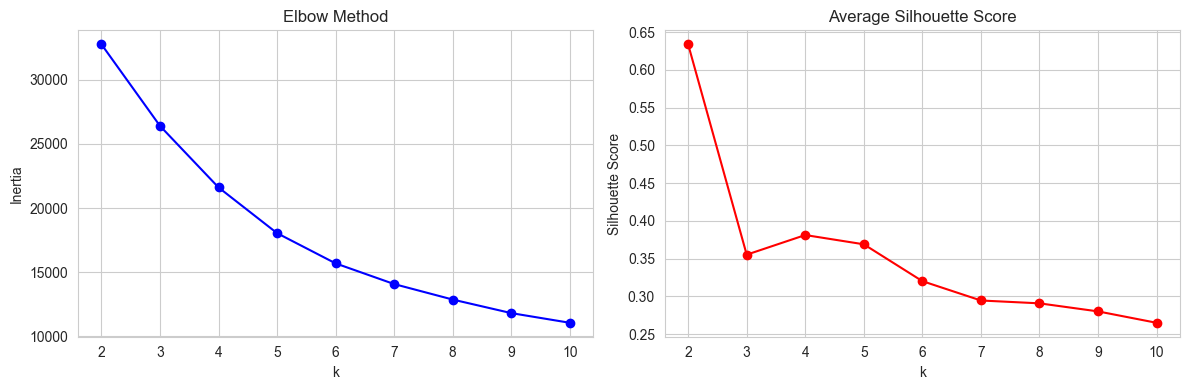

Selected k = 4


In [15]:
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.subplot(1,2,2)
plt.plot(k_range, sil_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Average Silhouette Score')
plt.tight_layout()
plt.show()

optimal_k = 4
print(f"Selected k = {optimal_k}")


In [16]:
def evaluate_clustering(model, X_scaled, name):
    labels = model.fit_predict(X_scaled)
    if len(set(labels)) < 2:
        return {'model': name, 'n_clusters': len(set(labels)), 
                'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': -1}
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    return {'model': name, 'n_clusters': len(set(labels)), 
            'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}

results = []
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
results.append(evaluate_clustering(kmeans, X_scaled, 'KMeans'))

hier = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
results.append(evaluate_clustering(hier, X_scaled, 'Hierarchical'))

best_db = None
best_sil = -1
for eps in np.arange(0.5, 1.6, 0.2):
    for min_samples in [5,10,15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labs = db.fit_predict(X_scaled)
        if len(set(labs)) > 1 and len(set(labs)) <= 10:
            sil = silhouette_score(X_scaled, labs)
            if sil > best_sil:
                best_sil = sil
                best_db = db
results.append(evaluate_clustering(best_db, X_scaled, 'DBSCAN'))

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
results.append(evaluate_clustering(gmm, X_scaled, 'GMM'))

results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.round(4))



=== Model Comparison ===
          model  n_clusters  silhouette  davies_bouldin  calinski_harabasz
0        KMeans           4      0.3813          1.0923          3189.6681
1  Hierarchical           4      0.3010          1.2522          2882.8476
2        DBSCAN           3      0.5125          1.4043          1597.3632
3           GMM           4      0.2312          1.4436          1730.8967


In [19]:
final_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_df['Segment'] = final_model.fit_predict(X_scaled)

seg_order = customer_df.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).index
name_map = {seg_order[0]: 'Champions', seg_order[1]: 'Regulars', 
            seg_order[2]: 'At-Risk', seg_order[3]: 'Low-Engagement'}
customer_df['SegmentName'] = customer_df['Segment'].map(name_map)


In [21]:
profile = customer_df.groupby('SegmentName').agg({
    'Monetary': ['mean', 'count', 'sum'],   # ← added 'sum'
    'Frequency': 'mean',
    'Recency': 'mean',
    'AvgBasketValue': 'mean',
    'UniqueProducts': 'mean',
    'ReturnsRatio': 'mean',
    'WeekendRatio': 'mean'
}).round(2)

profile[('Customer', '%')] = (profile[('Monetary', 'count')] / len(customer_df) * 100).round(1)
profile[('Revenue', '%')] = (profile[('Monetary', 'sum')] / customer_df['Monetary'].sum() * 100).round(1)

print("\n=== Segment Profiles ===")
print(profile)


=== Segment Profiles ===
               Monetary                   Frequency Recency AvgBasketValue  \
                   mean count         sum      mean    mean           mean   
SegmentName                                                                  
At-Risk          828.73   491   406904.29      2.76   94.43         305.93   
Champions       5745.35   929  5337428.36     10.90   29.39         477.91   
Low-Engagement   697.73  2398  1673156.11      2.39  110.99         302.78   
Regulars        1058.97   520   550664.49      2.52  118.48         438.65   

               UniqueProducts ReturnsRatio WeekendRatio Customer Revenue  
                         mean         mean         mean        %       %  
SegmentName                                                               
At-Risk                 63.10         0.11         0.85     11.3     5.1  
Champions              146.08         0.19         0.16     21.4    67.0  
Low-Engagement          32.92         0.03         0

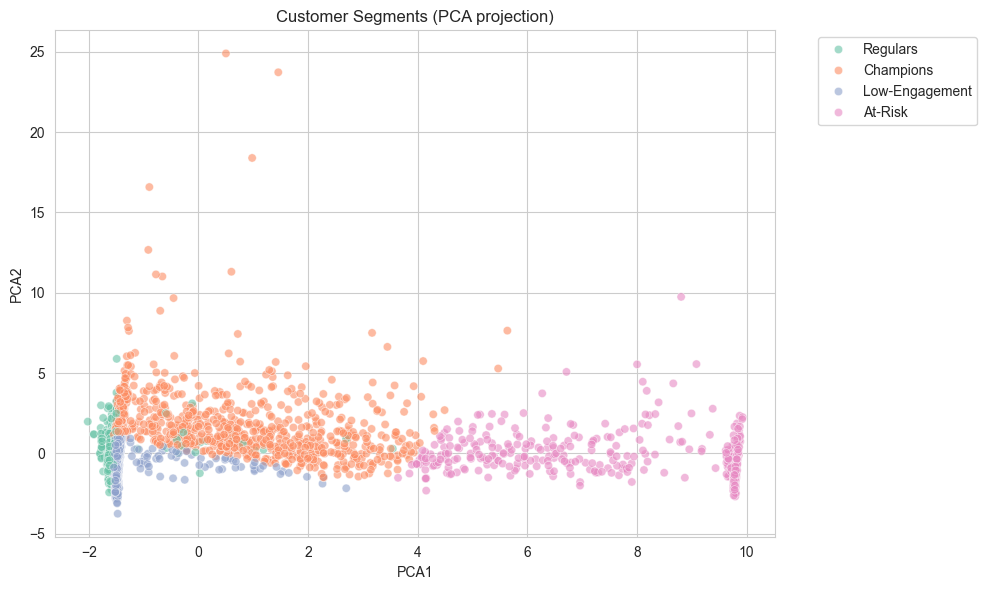

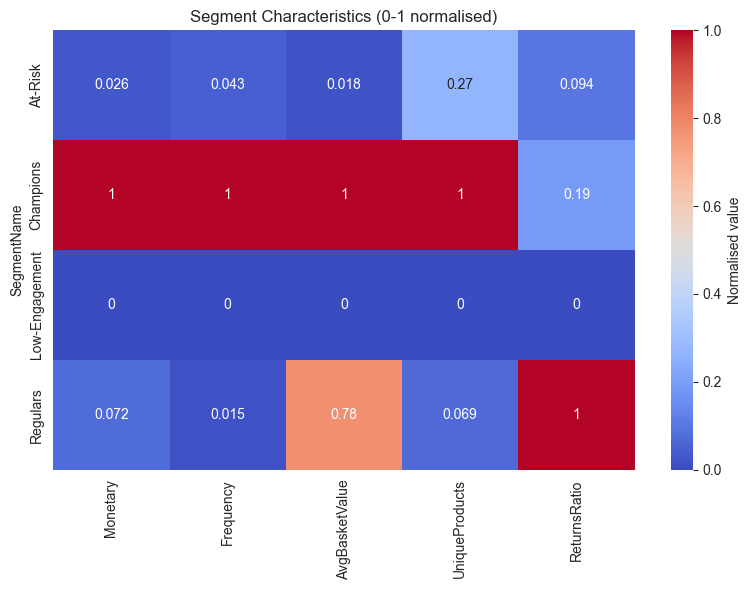

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
customer_df['PCA1'] = X_pca[:, 0]
customer_df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(data=customer_df, x='PCA1', y='PCA2', hue='SegmentName', palette='Set2', alpha=0.6)
plt.title('Customer Segments (PCA projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---------- Corrected Heatmap ----------
feat_names = ['Monetary', 'Frequency', 'AvgBasketValue', 'UniqueProducts', 'ReturnsRatio']

# Extract only the 'mean' values for these features (ignore 'count')
profile_means = profile[feat_names].xs('mean', axis=1, level=1)

# Normalise
scaler_norm = MinMaxScaler()
profile_scaled = scaler_norm.fit_transform(profile_means)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(pd.DataFrame(profile_scaled, index=profile_means.index, columns=feat_names),
            annot=True, cmap='coolwarm', cbar_kws={'label': 'Normalised value'})
plt.title('Segment Characteristics (0-1 normalised)')
plt.tight_layout()
plt.show()

In [26]:
customer_df.to_csv('customer_segments_final.csv', index=True)
print("\n Segmented data saved to 'customer_segments_final.csv'")
print("\nSample of final segments:")
print(customer_df[['Monetary', 'Frequency', 'Recency', 'SegmentName']].head(10))


 Segmented data saved to 'customer_segments_final.csv'

Sample of final segments:
            Monetary  Frequency  Recency     SegmentName
CustomerID                                              
12346.0       208.00          1      326        Regulars
12347.0      4268.40          7        2       Champions
12348.0      1589.79          4       75  Low-Engagement
12349.0      1451.50          1       19  Low-Engagement
12350.0       311.35          1      310  Low-Engagement
12352.0      1555.24          8       36  Low-Engagement
12353.0        89.00          1      204  Low-Engagement
12354.0      1079.40          1      232  Low-Engagement
12355.0       459.40          1      214  Low-Engagement
12356.0      2792.53          3       23  Low-Engagement


In [27]:
customer_df.groupby('SegmentName').count()

,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,WeekendRatio,AvgBasketValue,ReturnsInvoices,ReturnsRatio,Monetary_log,Frequency_log,AvgBasketValue_log,Recency_inv,Segment,PCA1,PCA2
SegmentName,,,,,,,,,,,,,,,,
At-Risk,491,491,491,491,491,491,491,491,491,491,491,491,491,491,491,491
Champions,929,929,929,929,929,929,929,929,929,929,929,929,929,929,929,929
Low-Engagement,2398,2398,2398,2398,2398,2398,2398,2398,2398,2398,2398,2398,2398,2398,2398,2398
Regulars,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520
